# 03 — Results analysis

Reads all per-run CSVs from `output/results/03_train_models/` and summarises model performance.

In [1]:
import glob
import os
import stylia
stylia.set_style("ersilia")
nc = stylia.NamedColors() 

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 300
plt.rcParams["xtick.minor.pad"] = 1   # default is 3.5
plt.rcParams['hatch.linewidth'] = 0.4  # previous pdf hatch linewidth

sns.set_theme(style="whitegrid", font_scale=1.1)

RESULTS_DIR = "../output/results/03_train_models"
FIGURES_DIR = "../output/plots"

In [2]:
# Load and concatenate all run CSVs
files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*.csv")))
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f"{len(files)} run files → {len(df)} rows")

# Map pathogen codes to full names
pathogens = pd.read_csv("../config/pathogens.csv")
pathogen_codes = dict(zip(pathogens["code"], pathogens["pathogen"]))

# Add compound / active counts from selected-datasets metadata
_meta = pd.read_csv("../data/processed/01b_selected_datasets.csv")[["pathogen", "name", "compounds", "positives"]]
df = df.merge(_meta, left_on=["pathogen", "dataset"], right_on=["pathogen", "name"], how="left").drop(columns="name")
cols = [i for i in df.columns if i not in ["compounds", "positives"]]
cols = cols[:3] + ["compounds", "positives"] + cols[3:]
df = df[cols]

# Show only performance
cols = [i for i in df.columns if 'time' not in i and 'onnx' not in i]
df[cols]

6 run files → 6 rows


,pathogen,dataset,mode,compounds,positives,n_train,n_test,n_pos_train,n_neg_train,n_pos_test,n_neg_test,auroc_lazy,aupr_lazy,aupr_baseline,sensitivity,specificity,auroc_rf,auroc_lr,auroc_xgb,head_score_cddd_rf,head_score_cddd_lr,head_score_cddd_xgb,pooler_cddd_mode,pooler_cddd_score,head_score_chemeleon_rf,head_score_chemeleon_lr,head_score_chemeleon_xgb,pooler_chemeleon_mode,pooler_chemeleon_score,head_score_morgan_rf,head_score_morgan_lr,head_score_morgan_xgb,pooler_morgan_mode,pooler_morgan_score,head_score_rdkit_rf,head_score_rdkit_lr,head_score_rdkit_xgb,pooler_rdkit_mode,pooler_rdkit_score,brier_score,brier_baseline,ece,prob_active_min,prob_active_p5,prob_active_p25,prob_active_p50,prob_active_p75,prob_active_p95,prob_active_max,prob_inactive_min,prob_inactive_p5,prob_inactive_p25,prob_inactive_p50,prob_inactive_p75,prob_inactive_p95,prob_inactive_max,optimal_cutoff
0,calbicans,G_ORG7_10.0,default,867,135,693,174,108,585,27,147,0.9393,0.7896,0.1552,0.8148,0.8639,0.9204,0.8502,0.9242,0.5842,0.6687,0.6297,gating,0.6707,0.7778,0.7611,0.7574,gating,0.7952,NaN,NaN,NaN,NaN,NaN,0.7506,NaN,0.7131,gating,0.7464,0.0668,0.1311,0.0685,0.0810,0.0857,0.2918,0.5859,0.7373,0.7989,0.8001,0.0599,0.0609,0.0635,0.0708,0.0921,0.2840,0.7263,0.1595
1,calbicans,G_ORG7_10.0,fast,867,135,693,174,108,585,27,147,0.9400,0.8114,0.1552,0.8889,0.8367,0.9204,0.8502,0.9242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7535,0.6999,0.7501,gating,0.7819,0.7506,NaN,0.7131,gating,0.7464,0.0646,0.1311,0.0713,0.0705,0.0792,0.2383,0.6692,0.7526,0.8173,0.8175,0.0614,0.0618,0.0638,0.0677,0.0849,0.3490,0.7340,0.1215
2,calbicans,G_ORG7_10.0,slow,867,135,693,174,108,585,27,147,0.9438,0.7979,0.1552,0.8519,0.8571,0.9204,0.8502,0.9242,0.5842,0.6687,0.6297,gating,0.6707,0.7778,0.7611,0.7574,gating,0.7952,0.7535,0.6999,0.7501,gating,0.7819,0.7506,NaN,0.7131,gating,0.7464,0.0658,0.1311,0.0678,0.0803,0.0907,0.3065,0.5893,0.7434,0.7938,0.7961,0.0602,0.0611,0.0638,0.0702,0.0883,0.3112,0.7131,0.1476
3,ecoli,G_ORG7_10.0,default,635,161,508,127,129,379,32,95,0.8868,0.8012,0.2520,0.5312,0.9684,0.9046,0.7660,0.9079,0.6879,0.6878,0.6877,gating,0.7263,0.7963,0.8008,0.7672,gating,0.8250,NaN,NaN,NaN,NaN,NaN,0.7790,NaN,0.7510,gating,0.7928,0.1129,0.1885,0.0972,0.0747,0.1004,0.1720,0.4503,0.7121,0.8186,0.8235,0.0706,0.0725,0.0789,0.0899,0.1278,0.2815,0.5422,0.3116
4,ecoli,G_ORG7_10.0,fast,635,161,508,127,129,379,32,95,0.9184,0.8543,0.2520,0.6875,0.9579,0.9046,0.7660,0.9079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7987,0.8059,0.8068,gating,0.8205,0.7790,NaN,0.7510,gating,0.7928,0.0979,0.1885,0.0905,0.0733,0.0927,0.2449,0.4983,0.7857,0.8437,0.8587,0.0707,0.0714,0.0744,0.0796,0.0992,0.2657,0.4241,0.2801
5,ecoli,G_ORG7_10.0,slow,635,161,508,127,129,379,32,95,0.9099,0.8363,0.2520,0.5625,0.9684,0.9046,0.7660,0.9079,0.6879,0.6878,0.6877,gating,0.7263,0.7963,0.8008,0.7672,gating,0.8250,0.7987,0.8059,0.8068,gating,0.8205,0.7790,NaN,0.7510,gating,0.7928,0.1064,0.1885,0.1101,0.0734,0.1082,0.2231,0.4277,0.7352,0.8250,0.8337,0.0700,0.0715,0.0773,0.0875,0.1254,0.2687,0.4954,0.3106


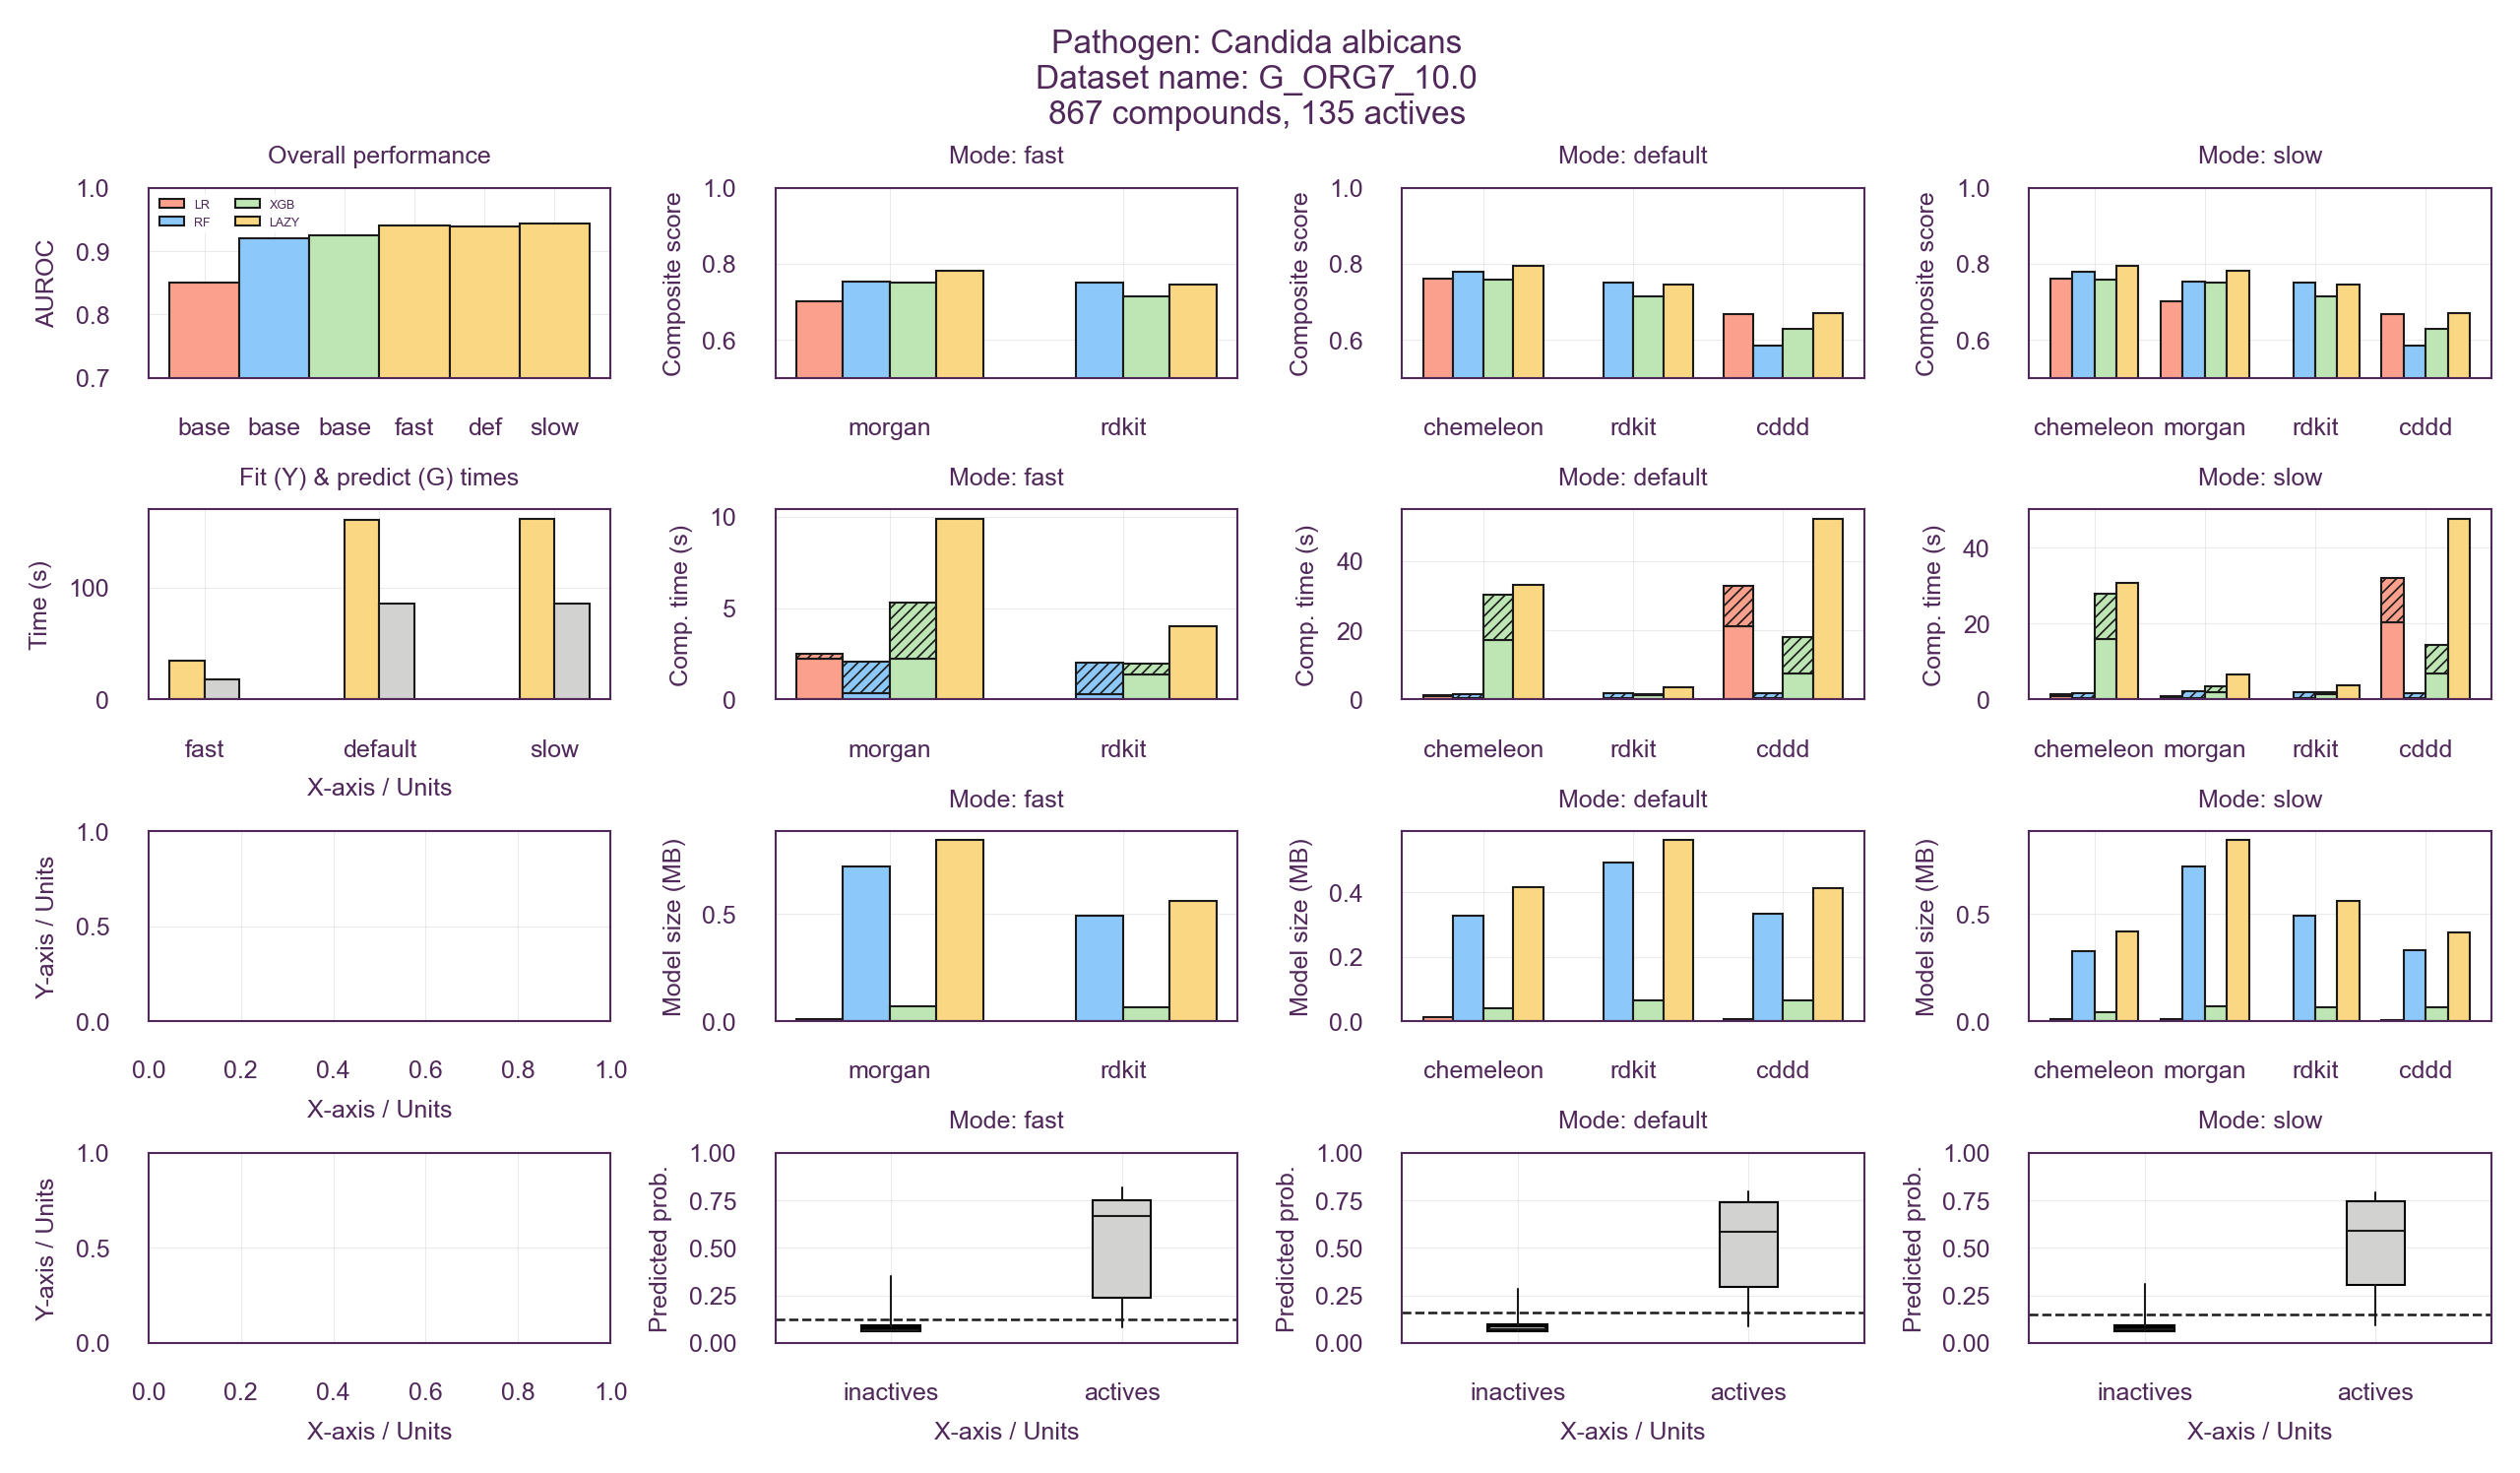

In [5]:
pathogen = "calbicans"
dataset = "G_ORG7_10.0"
df_subset = df[(df["pathogen"] == pathogen) & (df["dataset"] == dataset)]
modes = ['fast', 'default', 'slow']

stylia.set_format("print")

fig, axs = stylia.create_figure(4, 4, width=1.2, height=0.7)
actives =   df_subset["positives"].values[0]
compounds = df_subset["compounds"].values[0]
fig.suptitle(f"Pathogen: {pathogen_codes[pathogen]}\nDataset name: {dataset}\n{compounds} compounds, {actives} actives", fontsize=stylia.FONTSIZE_BIG)

################################################
######### BASELINE PERFORMANCE (AUROC) #########
################################################

ax = axs.next()
W = 0.2
ax.set_title("Overall performance")
ax.set_ylim([0.7, 1])
ax.set_yticks([0.7, 0.8, 0.9, 1])
ax.set_ylabel("AUROC")
ax.bar(-3/2*W, df_subset[df_subset["mode"] == 'fast']["auroc_lr"].mean(), color=nc.orange, width=W, ec='k', lw=0.5, label="LR")
ax.bar(-1/2*W, df_subset[df_subset["mode"] == 'fast']["auroc_rf"].mean(), color=nc.blue, width=W, ec='k', lw=0.5, label="RF")
ax.bar(1/2*W, df_subset[df_subset["mode"] == 'fast']["auroc_xgb"].mean(), color=nc.mint, width=W, ec='k', lw=0.5, label='XGB')
ax.bar(3/2*W, df_subset[df_subset["mode"] == 'fast']["auroc_lazy"].mean(), color=nc.yellow, width=W, ec='k', lw=0.5, label='LAZY')
ax.bar(5/2*W, df_subset[df_subset["mode"] == 'default']["auroc_lazy"].mean(), color=nc.yellow, width=W, ec='k', lw=0.5)
ax.bar(7/2*W, df_subset[df_subset["mode"] == 'slow']["auroc_lazy"].mean(), color=nc.yellow, width=W, ec='k', lw=0.5)
ax.set_xlabel("")
ax.set_xticks([-3/2*W, -1/2*W, 1/2*W, 3/2*W, 5/2*W, 7/2*W])
ax.set_xticklabels(["base", "base", "base", "fast", "def", "slow"], rotation=0)
ax.legend(prop={'size': 3}, ncol=2, loc='upper left')

################################################
############### COMPOSITE SCORES ###############
################################################

ax = axs.next()
W = 0.2
mode = 'fast'
ax.set_title(f"Mode: {mode}")
ax.set_xlabel("")
ax.set_ylim([0.5, 1])
ax.set_ylabel("Composite score")
descs = ['morgan', 'rdkit']
for x, desc in enumerate(descs):
    ax.bar(x - 3/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_lr"].values[0], color=nc.orange, width=W, ec='k', lw=0.5)
    ax.bar(x - 1/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_rf"].values[0], color=nc.blue, width=W, ec='k', lw=0.5)
    ax.bar(x + 1/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_xgb"].values[0], color=nc.mint, width=W, ec='k', lw=0.5)
    ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"pooler_{desc}_score"].values[0], color=nc.yellow, width=W, ec='k', lw=0.5)
ax.set_xticks([i for i in range(len(descs))])
ax.set_xticklabels(descs, rotation=0)


ax = axs.next()
W = 0.2
mode = 'default'
ax.set_title(f"Mode: {mode}")
ax.set_xlabel("")
ax.set_ylim([0.5, 1])
ax.set_ylabel("Composite score")
descs = ['chemeleon', 'rdkit', 'cddd']
for x, desc in enumerate(descs):
    ax.bar(x - 3/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_lr"].values[0], color=nc.orange, width=W, ec='k', lw=0.5)
    ax.bar(x - 1/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_rf"].values[0], color=nc.blue, width=W, ec='k', lw=0.5)
    ax.bar(x + 1/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_xgb"].values[0], color=nc.mint, width=W, ec='k', lw=0.5)
    ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"pooler_{desc}_score"].values[0], color=nc.yellow, width=W, ec='k', lw=0.5)
ax.set_xticks([i for i in range(len(descs))])
ax.set_xticklabels(descs, rotation=0)


ax = axs.next()
W = 0.2
mode = 'slow'
ax.set_title(f"Mode: {mode}")
ax.set_xlabel("")
ax.set_ylim([0.5, 1])
ax.set_ylabel("Composite score")
descs = ['chemeleon', 'morgan', 'rdkit', 'cddd']
for x, desc in enumerate(descs):
    ax.bar(x - 3/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_lr"].values[0], color=nc.orange, width=W, ec='k', lw=0.5)
    ax.bar(x - 1/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_rf"].values[0], color=nc.blue, width=W, ec='k', lw=0.5)
    ax.bar(x + 1/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_xgb"].values[0], color=nc.mint, width=W, ec='k', lw=0.5)
    ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"pooler_{desc}_score"].values[0], color=nc.yellow, width=W, ec='k', lw=0.5)
ax.set_xticks([i for i in range(len(descs))])
ax.set_xticklabels(descs, rotation=0)



################################################
################## TIMES ###################
################################################

ax = axs.next()
W = 0.2
ax.set_title("Fit (Y) & predict (G) times")
ax.set_ylabel("Time (s)")
for x, mode in enumerate(['fast', 'default', 'slow']):
    fit_t  = df_subset[df_subset['mode'] == mode]['time_lazyqsar_fit_s'].values[0]
    pred_t = df_subset[df_subset['mode'] == mode]['predict_time_1k_s'].values[0]
    ax.bar(x - W/2, fit_t,  color=nc.yellow, width=W, ec='k', lw=0.5, label='fit'     if x == 0 else '')
    ax.bar(x + W/2, pred_t, color=nc.gray,   width=W, ec='k', lw=0.5, label='pred/1k' if x == 0 else '')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['fast', 'default', 'slow'])

ax = axs.next()
W = 0.2
mode = 'fast'
ax.set_title(f"Mode: {mode}")
ax.set_xlabel("")
ax.set_ylabel("Comp. time (s)")
descs = ['morgan', 'rdkit']
for x, desc in enumerate(descs):
    fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_lr_fit_s"].values[0]
    cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_lr_calibration_s"].values[0]
    ax.bar(x - 3/2*W, fit, color=nc.orange, width=W, ec='k', lw=0.5)
    ax.bar(x - 3/2*W, bottom=fit, height=cal, color=nc.orange, width=W, ec='k', lw=0.5, hatch='/////////')
    fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_rf_fit_s"].values[0]
    cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_rf_calibration_s"].values[0]
    ax.bar(x - 1/2*W, fit, color=nc.blue, width=W, ec='k', lw=0.5)
    ax.bar(x - 1/2*W, bottom=fit, height=cal, color=nc.blue, width=W, ec='k', lw=0.5, hatch='/////////')
    fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_xgb_fit_s"].values[0]
    cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_xgb_calibration_s"].values[0]
    ax.bar(x + 1/2*W, fit, color=nc.mint, width=W, ec='k', lw=0.5)
    ax.bar(x + 1/2*W, bottom=fit, height=cal, color=nc.mint, width=W, ec='k', lw=0.5, hatch='/////////')
    ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"time_{desc}_total_s"].values[0], color=nc.yellow, width=W, ec='k', lw=0.5)
ax.set_xticks([i for i in range(len(descs))])
ax.set_xticklabels(descs, rotation=0)

ax = axs.next()
W = 0.2
mode = 'default'
ax.set_title(f"Mode: {mode}")
ax.set_xlabel("")
ax.set_ylabel("Comp. time (s)")
descs = ['chemeleon', 'rdkit', 'cddd']
for x, desc in enumerate(descs):
    fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_lr_fit_s"].values[0]
    cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_lr_calibration_s"].values[0]
    ax.bar(x - 3/2*W, fit, color=nc.orange, width=W, ec='k', lw=0.5)
    ax.bar(x - 3/2*W, bottom=fit, height=cal, color=nc.orange, width=W, ec='k', lw=0.5, hatch='/////////')
    fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_rf_fit_s"].values[0]
    cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_rf_calibration_s"].values[0]
    ax.bar(x - 1/2*W, fit, color=nc.blue, width=W, ec='k', lw=0.5)
    ax.bar(x - 1/2*W, bottom=fit, height=cal, color=nc.blue, width=W, ec='k', lw=0.5, hatch='/////////')
    fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_xgb_fit_s"].values[0]
    cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_xgb_calibration_s"].values[0]
    ax.bar(x + 1/2*W, fit, color=nc.mint, width=W, ec='k', lw=0.5)
    ax.bar(x + 1/2*W, bottom=fit, height=cal, color=nc.mint, width=W, ec='k', lw=0.5, hatch='/////////')
    ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"time_{desc}_total_s"].values[0], color=nc.yellow, width=W, ec='k', lw=0.5)
ax.set_xticks([i for i in range(len(descs))])
ax.set_xticklabels(descs, rotation=0)


ax = axs.next()
W = 0.2
mode = 'slow'
ax.set_title(f"Mode: {mode}")
ax.set_xlabel("")
ax.set_ylabel("Comp. time (s)")
descs = ['chemeleon', 'morgan', 'rdkit', 'cddd']
for x, desc in enumerate(descs):
    fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_lr_fit_s"].values[0]
    cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_lr_calibration_s"].values[0]
    ax.bar(x - 3/2*W, fit, color=nc.orange, width=W, ec='k', lw=0.5)
    ax.bar(x - 3/2*W, bottom=fit, height=cal, color=nc.orange, width=W, ec='k', lw=0.5, hatch='/////////')
    fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_rf_fit_s"].values[0]
    cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_rf_calibration_s"].values[0]
    ax.bar(x - 1/2*W, fit, color=nc.blue, width=W, ec='k', lw=0.5)
    ax.bar(x - 1/2*W, bottom=fit, height=cal, color=nc.blue, width=W, ec='k', lw=0.5, hatch='/////////')
    fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_xgb_fit_s"].values[0]
    cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_xgb_calibration_s"].values[0]
    ax.bar(x + 1/2*W, fit, color=nc.mint, width=W, ec='k', lw=0.5)
    ax.bar(x + 1/2*W, bottom=fit, height=cal, color=nc.mint, width=W, ec='k', lw=0.5, hatch='/////////')
    ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"time_{desc}_total_s"].values[0], color=nc.yellow, width=W, ec='k', lw=0.5)
ax.set_xticks([i for i in range(len(descs))])
ax.set_xticklabels(descs, rotation=0)


################################################
################## ONNX SIZE ###################
################################################

ax = axs.next()
ax = axs.next()
W = 0.2
mode = 'fast'
ax.set_title(f"Mode: {mode}")
ax.set_xlabel("")
ax.set_ylabel("Model size (MB)")
descs = ['morgan', 'rdkit']
for x, desc in enumerate(descs):
    ax.bar(x - 3/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_lr_kb"].values[0]/1000, color=nc.orange, width=W, ec='k', lw=0.5)
    ax.bar(x - 1/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_rf_kb"].values[0]/1000, color=nc.blue, width=W, ec='k', lw=0.5)
    ax.bar(x + 1/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_xgb_kb"].values[0]/1000, color=nc.mint, width=W, ec='k', lw=0.5)
    ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_total_kb"].values[0]/1000, color=nc.yellow, width=W, ec='k', lw=0.5)
ax.set_xticks([i for i in range(len(descs))])
ax.set_xticklabels(descs, rotation=0)


ax = axs.next()
W = 0.2
mode = 'default'
ax.set_title(f"Mode: {mode}")
ax.set_xlabel("")
ax.set_ylabel("Model size (MB)")
descs = ['chemeleon', 'rdkit', 'cddd']
for x, desc in enumerate(descs):
    ax.bar(x - 3/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_lr_kb"].values[0]/1000, color=nc.orange, width=W, ec='k', lw=0.5)
    ax.bar(x - 1/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_rf_kb"].values[0]/1000, color=nc.blue, width=W, ec='k', lw=0.5)
    ax.bar(x + 1/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_xgb_kb"].values[0]/1000, color=nc.mint, width=W, ec='k', lw=0.5)
    ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_total_kb"].values[0]/1000, color=nc.yellow, width=W, ec='k', lw=0.5)
ax.set_xticks([i for i in range(len(descs))])
ax.set_xticklabels(descs, rotation=0)

ax = axs.next()
W = 0.2
mode = 'slow'
ax.set_title(f"Mode: {mode}")
ax.set_xlabel("")
ax.set_ylabel("Model size (MB)")
descs = ['chemeleon', 'morgan', 'rdkit', 'cddd']
for x, desc in enumerate(descs):
    ax.bar(x - 3/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_lr_kb"].values[0]/1000, color=nc.orange, width=W, ec='k', lw=0.5)
    ax.bar(x - 1/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_rf_kb"].values[0]/1000, color=nc.blue, width=W, ec='k', lw=0.5)
    ax.bar(x + 1/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_xgb_kb"].values[0]/1000, color=nc.mint, width=W, ec='k', lw=0.5)
    ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_total_kb"].values[0]/1000, color=nc.yellow, width=W, ec='k', lw=0.5)
ax.set_xticks([i for i in range(len(descs))])
ax.set_xticklabels(descs, rotation=0)


################################################
######### PREDICTED PROBABILITY DIST ##########
################################################

ax = axs.next()  # skip first column (consistent with rows above)
for mode in ['fast', 'default', 'slow']:
    ax = axs.next()
    row = df_subset[df_subset['mode'] == mode].iloc[0]

    stats_inact = dict(
        med=row['prob_inactive_p50'], q1=row['prob_inactive_p25'], q3=row['prob_inactive_p75'],
        whislo=row['prob_inactive_p5'], whishi=row['prob_inactive_p95'], fliers=[]
    )
    stats_act = dict(
        med=row['prob_active_p50'], q1=row['prob_active_p25'], q3=row['prob_active_p75'],
        whislo=row['prob_active_p5'], whishi=row['prob_active_p95'], fliers=[]
    )

    bp = ax.bxp([stats_inact, stats_act], positions=[0, 1], widths=0.25,
                patch_artist=True, showfliers=False)
    bp['boxes'][0].set_facecolor(nc.gray)
    bp['boxes'][1].set_facecolor(nc.gray)
    bp['boxes'][1].set_linewidth(0.5)
    for element in ['whiskers', 'caps', 'medians']:
        for line in bp[element]:
            line.set_color('k')
            line.set_linewidth(0.5)
            if element == 'caps': line.set_linewidth(0)

    ax.axhline(row['optimal_cutoff'], color='k', linestyle='--', lw=0.6, label=f"cutoff={row['optimal_cutoff']:.2f}")
    ax.set_ylim([0, 1])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['inactives', 'actives'])
    ax.set_title(f"Mode: {mode}")
    ax.set_ylabel("Predicted prob.")

plt.tight_layout()
plt.show()

In [4]:
[i for i in df.columns if 'onnx' in i ]

['onnx_cddd_rf_kb',
 'onnx_cddd_lr_kb',
 'onnx_cddd_xgb_kb',
 'onnx_cddd_preprocessor_kb',
 'onnx_cddd_total_kb',
 'onnx_chemeleon_rf_kb',
 'onnx_chemeleon_lr_kb',
 'onnx_chemeleon_xgb_kb',
 'onnx_chemeleon_preprocessor_kb',
 'onnx_chemeleon_total_kb',
 'onnx_morgan_rf_kb',
 'onnx_morgan_lr_kb',
 'onnx_morgan_xgb_kb',
 'onnx_morgan_preprocessor_kb',
 'onnx_morgan_total_kb',
 'onnx_rdkit_rf_kb',
 'onnx_rdkit_lr_kb',
 'onnx_rdkit_xgb_kb',
 'onnx_rdkit_preprocessor_kb',
 'onnx_rdkit_total_kb']